In [1]:
import numpy as np
from dataclasses import dataclass
import matplotlib.pyplot as plt

In [2]:
@dataclass
class Interval:
    index: int
    left: float
    right: float
    collocation_points: np.ndarray

    @property
    def width(self):
        return self.right - self.left

    @property
    def center(self):
        return (self.left + self.right) / 2




In [3]:

class LagrangeCollocation:

    @staticmethod
    def barycentric_weights(x):
        n = len(x)
        w = np.ones(n)

        for j in range(n):
            for k in range(n):
                if j != k:
                    w[j] /= (x[j] - x[k])

        return w

    @staticmethod
    def barycentric_differentiation_matrix(x):
        n = len(x)
        w = LagrangeCollocation.barycentric_weights(x)

        D = np.zeros((n, n))

        for i in range(n):
            for j in range(n):
                if i != j:
                    D[i, j] = w[j] / (w[i] * (x[i] - x[j]))

        for i in range(n):
            D[i, i] = -np.sum(D[i, :])

        return D

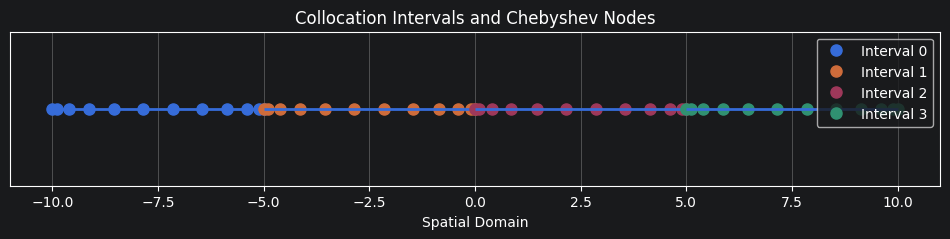

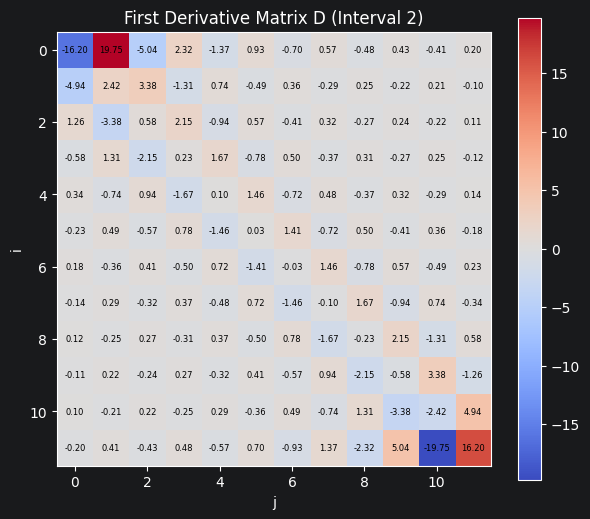

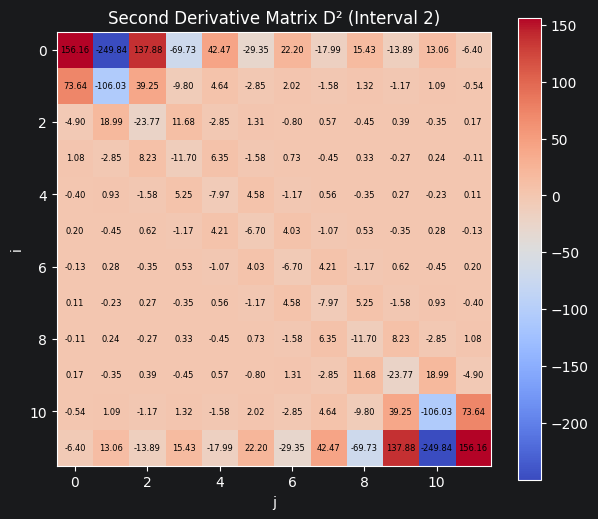

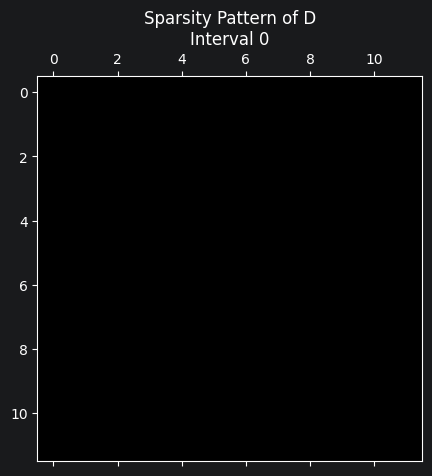

In [4]:
class IntervalCollocation:

    def __init__(
        self,
        domain_start: float,
        domain_end: float,
        num_intervals: int,
        points_per_interval: int
    ):

        self.domain_start = domain_start
        self.domain_end = domain_end
        self.num_intervals = num_intervals
        self.points_per_interval = points_per_interval

        self.intervals = []
        self.diff_matrices = []
        self.diff2_matrices = []

        self._setup_intervals()

    def _setup_intervals(self):

        interval_width = (
            self.domain_end - self.domain_start
        ) / self.num_intervals

        for i in range(self.num_intervals):

            left = self.domain_start + i * interval_width
            right = left + interval_width
            points = self._chebyshev_lobatto_points(left, right)

            D = LagrangeCollocation.barycentric_differentiation_matrix(points)
            D2 = D @ D

            self.intervals.append({
                'index': i,
                'left': left,
                'right': right,
                'points': points,
            })

            self.diff_matrices.append(D)
            self.diff2_matrices.append(D2)

    def _chebyshev_lobatto_points(self, left: float, right: float) -> np.ndarray:

        n = self.points_per_interval

        xi = np.cos(np.pi * np.arange(n) / (n - 1))
        points = 0.5 * (right - left) * (xi + 1) + left
        return points[::-1]

    def visualise_intervals(self):

        plt.figure(figsize=(12, 2))

        for interval in self.intervals:

            pts = interval['points']

            plt.plot(
                pts,
                np.zeros_like(pts),
                'o',
                markersize=8,
                label=f"Interval {interval['index']}"
            )

            plt.hlines(
                0,
                interval['left'],
                interval['right'],
                linewidth=2
            )

        plt.yticks([])
        plt.xlabel("Spatial Domain")
        plt.title("Collocation Intervals and Chebyshev Nodes")
        plt.grid(True)
        plt.legend()
        plt.show()

    def visualise_diff_matrix(self, interval_index):

        D = self.diff_matrices[interval_index]

        self._plot_matrix_with_numbers(
            D,
            f"First Derivative Matrix D (Interval {interval_index})"
        )

    def visualise_diff2_matrix(self, interval_index):

        D2 = self.diff2_matrices[interval_index]

        self._plot_matrix_with_numbers(
            D2,
            f"Second Derivative Matrix D² (Interval {interval_index})"
        )

    def visualise_sparsity(self, interval_index):

        D = self.diff_matrices[interval_index]

        plt.figure(figsize=(5, 5))

        plt.spy(D)

        plt.title(f"Sparsity Pattern of D\nInterval {interval_index}")

        plt.show()

    def _plot_matrix_with_numbers(self, M, title):
        fig, ax = plt.subplots(figsize=(7, 6))

        im = ax.imshow(M, cmap='coolwarm')

        plt.colorbar(im, ax=ax)

        n, m = M.shape

        for i in range(n):
            for j in range(m):
                ax.text(
                    j, i,
                    f"{M[i, j]:.2f}",
                    ha="center",
                    va="center",
                    fontsize=6,
                    color="black"
                )

        ax.set_title(title)
        ax.set_xlabel("j")
        ax.set_ylabel("i")

        plt.show()

# Test

colloc = IntervalCollocation(
    domain_start=-10,
    domain_end=10,
    num_intervals=4,
    points_per_interval=12
)

colloc.visualise_intervals()

colloc.visualise_diff_matrix(2)

colloc.visualise_diff2_matrix(2)

colloc.visualise_sparsity(0)

In [5]:

class GlobalAssembler:
    def __init__(self, interval_collocations: IntervalCollocation, s, delta):
        self.ic = interval_collocations
        self.s = s
        self.delta = delta
        self.m = self.ic.points_per_interval
        self.E = self.ic.num_intervals

        self.total_unknowns = self.E * self.m

        self.total_equations = self.E * self.m + 3 * (self.E - 1) + 2

    def split_U(self, u):
        return [
            u[e * self.m:(e + 1) * self.m] for e in range(self.E)
        ]

    def residual(self, U): # Residual is overdetermined, end points are equation twice, need to remove both endpoints of an interval
    # Becuase currenlty the system is overdetermined. Replace with a better residual, maybe sobolev norm with extentsion.
        u_intervals = self.split_U(U)
        F = []

        # Collocation residuals (one block per element)
        for e in range(self.E):
            u = u_intervals[e]
            D = self.ic.diff_matrices[e]
            D2 = self.ic.diff2_matrices[e]
            c = u - self.s
            Fe = (
                -self.s * c
                + u
                - 0.5 * (u ** 2) * c
                + self.s * c * (D2 @ u)
                - self.delta * c * (D @ u)
            )
            F.append(Fe)

        F = np.concatenate(F)

        # Interface continuity conditions
        interface_F = []
        for e in range(self.E - 1):
            uL = u_intervals[e]
            uR = u_intervals[e + 1]

            # Continuity of solution
            interface_F.append(uL[-1] - uR[0])

            # Continuity of first derivative
            D_L = self.ic.diff_matrices[e]
            D_R = self.ic.diff_matrices[e + 1]
            interface_F.append((D_L @ uL)[-1] - (D_R @ uR)[0])

            # Continuity of second derivative
            D2_L = self.ic.diff2_matrices[e]
            D2_R = self.ic.diff2_matrices[e + 1]
            interface_F.append((D2_L @ uL)[-1] - (D2_R @ uR)[0])

        if interface_F:
            F = np.concatenate([F, np.array(interface_F)])

        bc = []
        u_0 = u_intervals[0][0]
        bc.append(u_0 - self.s)   # left BC:  u(x_0) = s
        u_N = u_intervals[-1][-1]
        bc.append(u_N)             # right BC: u(x_N) = 0
        F = np.concatenate([F, np.array(bc)])

        return F

    def jacobian(self, U):
        u_intervals = self.split_U(U)

        J = np.zeros((self.total_equations, self.total_unknowns))
        row = 0
        for e in range(self.E):
            u = u_intervals[e]
            D = self.ic.diff_matrices[e]
            D2 = self.ic.diff2_matrices[e]
            c = u - self.s

            diag_c = np.diag(c)
            diag_u = np.diag(u)

            J_local = (
                (1.0 - self.s) * np.eye(self.m)
                - 0.5 * (2.0 * diag_u * diag_c + np.diag(u ** 2))
                + self.s * (np.diag(D2 @ u) + diag_c @ D2)
                - self.delta * (np.diag(D @ u) + diag_c @ D)
            )

            col = e * self.m
            J[row:row + self.m, col:col + self.m] = J_local
            row += self.m


        for e in range(self.E - 1):
            # continuity of u
            J[row, (e + 1) * self.m - 1] = 1.0
            J[row, (e + 1) * self.m] = -1.0
            row += 1

            # continuity of u'
            D_L = self.ic.diff_matrices[e]
            D_R = self.ic.diff_matrices[e + 1]
            J[row, e * self.m:(e + 1) * self.m] = D_L[-1, :]
            J[row, (e + 1) * self.m:(e + 2) * self.m] = -D_R[0, :]
            row += 1

            # continuity of u''
            D2_L = self.ic.diff2_matrices[e]
            D2_R = self.ic.diff2_matrices[e + 1]
            J[row, e * self.m:(e + 1) * self.m] = D2_L[-1, :]
            J[row, (e + 1) * self.m:(e + 2) * self.m] = -D2_R[0, :]
            row += 1

        J[row, 0] = 1.0
        row += 1
        J[row, -1] = 1.0
        row += 1

        return J

    def initial_guess(self):
        x_nodes = np.concatenate([
            iv['points'] for iv in self.ic.intervals
        ])
        return (self.s / 2.0) * (1.0 - np.tanh(x_nodes))

    def newton_solver(self):
        U = self.initial_guess()

        for k in range(100):
            for e in range(ic.num_intervals):
                D  = ic.diff_matrices[e]
                D2 = ic.diff2_matrices[e]
            F = self.residual(U)
            normF = np.linalg.norm(F)

            if normF < 1e-10:
                print("Converged")
                break

            J = self.jacobian(U)
            dU, _, _, _ = np.linalg.lstsq(J, -F, rcond=None)
            U = U + dU

        return U

Explaining the Jacobian Hell:
Given the orignal equation local problem is $-s(u-s)+u-\frac{1}{2}u^2(u-s)-s(u-s)u''-\delta(u-s)u'$ then as $\frac{d}{d\xi} = D$, let $\circ$ denote Hadamard product

$s(u-s)+u-\frac{1}{2}u^2(u-s)-s(u-s)u''-\delta(u-s)u' \implies s(u-s\textbf{1})+u-\frac{1}{2}u^{\circ 2}\circ(u-s\textbf{1})-s\text{diag}(u-s\textbf{1})D^2u+\delta \text{diag}(u-s\textbf{1})Du$

As we require the diag to an identity matrix times $(u-s)$, this note is for me

Then taking the derivative with respect to u of this unholy monstrosity

$\frac{d}{du}[(u-s)D^2 u] = \text{diag}(u-s)D^2 + \text{diag}(D^2u)$

  s = 0.50   delta = 0.10

  s = 0.50   delta = 0.50

  s = 0.50   delta = 1.00

  s = 0.50   delta = 10.00

  s = 1.00   delta = 0.10

  s = 1.00   delta = 0.50

  s = 1.00   delta = 1.00

  s = 1.00   delta = 10.00

  s = 1.50   delta = 0.10

  s = 1.50   delta = 0.50

  s = 1.50   delta = 1.00

  s = 1.50   delta = 10.00

  s = 2.00   delta = 0.10

  s = 2.00   delta = 0.50

  s = 2.00   delta = 1.00

  s = 2.00   delta = 10.00



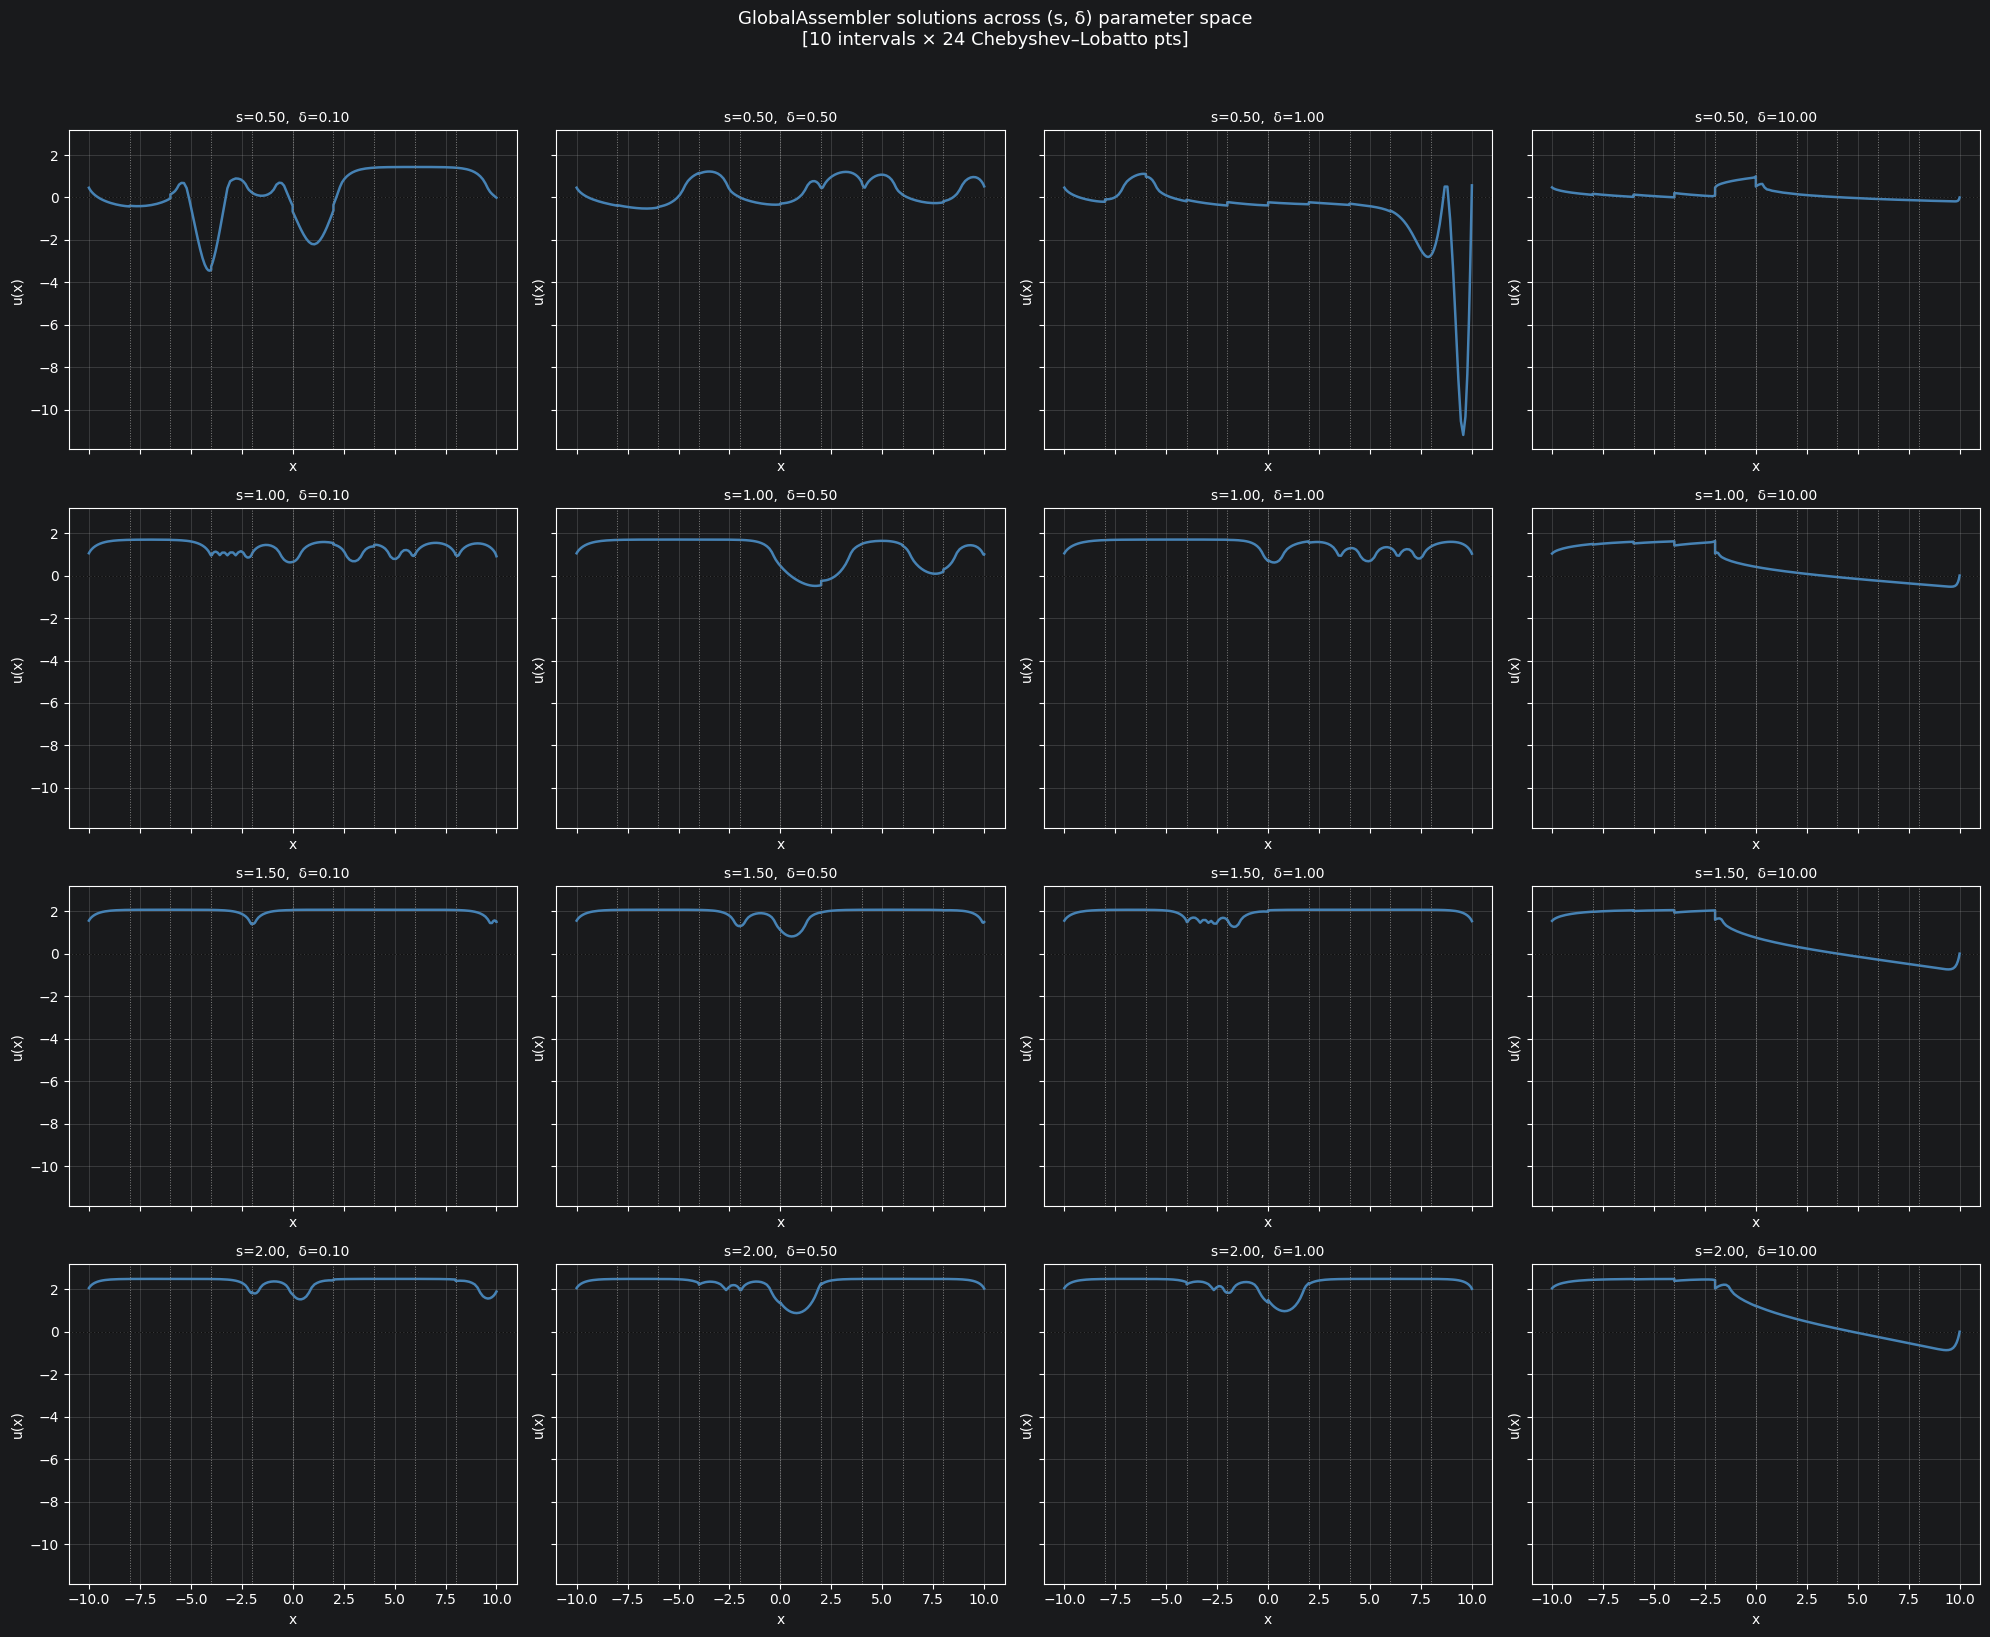


     s   delta   converged         ||U||
----------------------------------------
  0.50    0.10        True    1.9435e+01
  0.50    0.50        True    9.2836e+00
  0.50    1.00        True    2.7272e+01
  0.50   10.00        True    4.7289e+00
  1.00    0.10        True    2.0467e+01
  1.00    0.50        True    2.0613e+01
  1.00    1.00        True    2.2473e+01
  1.00   10.00        True    1.5348e+01
  1.50    0.10        True    3.0906e+01
  1.50    0.50        True    2.9503e+01
  1.50    1.00        True    3.0230e+01
  1.50   10.00        True    2.0724e+01
  2.00    0.10        True    3.6235e+01
  2.00    0.50        True    3.5526e+01
  2.00    1.00        True    3.5510e+01
  2.00   10.00        True    2.6095e+01


In [7]:
from itertools import product

s_values     = [0.5, 1.0, 1.5,2]
delta_values = [0.1, 0.5, 1.0,10]

DOMAIN_START       = -10
DOMAIN_END         =  10
NUM_INTERVALS      =   10
POINTS_PER_INTERVAL=  24


results = []

for s, delta in product(s_values, delta_values):
    print("=" * 60)
    print(f"  s = {s:.2f}   delta = {delta:.2f}")
    print("=" * 60)

    ic = IntervalCollocation(
        domain_start        = DOMAIN_START,
        domain_end          = DOMAIN_END,
        num_intervals       = NUM_INTERVALS,
        points_per_interval = POINTS_PER_INTERVAL,
    )

    assembler = GlobalAssembler(ic, s=s, delta=delta)

    try:
        U = assembler.newton_solver()
        converged = True
    except np.linalg.LinAlgError as exc:
        print(f"  Linear solve failed: {exc}")
        U = None
        converged = False

    x_all = np.concatenate([iv['points'] for iv in ic.intervals])

    results.append({
        's': s,
        'delta': delta,
        'U': U,
        'x': x_all,
        'converged': converged,
    })
    print()

fig, axes = plt.subplots(
    len(s_values), len(delta_values),
    figsize=(5 * len(delta_values), 4 * len(s_values)),
    sharex=True, sharey=True,
)

for res in results:
    row = s_values.index(res['s'])
    col = delta_values.index(res['delta'])
    ax  = axes[row][col]

    ax.set_title(f"s={res['s']:.2f},  δ={res['delta']:.2f}", fontsize=10)
    ax.axhline(0, color='k', linewidth=0.5, linestyle='--')

    if res['converged'] and res['U'] is not None:
        order = np.argsort(res['x'])
        ax.plot(res['x'][order], res['U'][order], color='steelblue', linewidth=1.8)

        for iv in IntervalCollocation(
            DOMAIN_START, DOMAIN_END,
            NUM_INTERVALS, POINTS_PER_INTERVAL
        ).intervals[1:]:
            ax.axvline(iv['left'], color='gray', linewidth=0.7, linestyle=':')
    else:
        ax.text(0.5, 0.5, 'Did not converge',
                ha='center', va='center', transform=ax.transAxes,
                color='red', fontsize=9)

    ax.set_xlabel("x")
    ax.set_ylabel("u(x)")
    ax.grid(True, alpha=0.3)

fig.suptitle(
    "GlobalAssembler solutions across (s, δ) parameter space\n"
    f"[{NUM_INTERVALS} intervals × {POINTS_PER_INTERVAL} Chebyshev–Lobatto pts]",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

print(f"\n{'s':>6}  {'delta':>6}  {'converged':>10}  {'||U||':>12}")
print("-" * 40)
for res in results:
    norm_str = f"{np.linalg.norm(res['U']):.4e}" if res['U'] is not None else "—"
    print(f"{res['s']:>6.2f}  {res['delta']:>6.2f}  {str(res['converged']):>10}  {norm_str:>12}")